<a href="https://www.kaggle.com/code/sonawanelalitsunil/swiggy-restaurant-dataset-india-ml?scriptVersionId=260571817" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/swiggy-restaurant-data-india/swiggy_all_menus_india.csv


## Title:
Swiggy Restaurant Dataset – India

## Description:
This dataset provides detailed information about restaurants listed on Swiggy in India. It typically includes attributes such as restaurant name, location, cuisine type, average cost, ratings, delivery time, and popularity. The data can be used to analyze customer preferences, explore food trends across regions, study pricing patterns, evaluate restaurant performance, and build recommendation systems. It is highly valuable for food-tech research, business intelligence, and machine learning applications like demand forecasting and sentiment-based analysis.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/swiggy-restaurant-data-india/swiggy_all_menus_india.csv")

In [3]:
df.head()

,State,City,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,0.0,0
1,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,0.0,0


In [4]:
df.tail()

,State,City,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,0.0,0
197426,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,0.0,0
197427,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,0.0,0
197428,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,0.0,0
197429,Sikkim,Gangtok,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,0.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   State            197430 non-null  object 
 1   City             197430 non-null  object 
 2   Restaurant Name  197430 non-null  object 
 3   Location         197430 non-null  object 
 4   Category         197430 non-null  object 
 5   Dish Name        197430 non-null  object 
 6   Price (INR)      197430 non-null  float64
 7   Rating           197430 non-null  float64
 8   Rating Count     197430 non-null  int64  
dtypes: float64(2), int64(1), object(6)
memory usage: 13.6+ MB


In [6]:
df.describe()

,Price (INR),Rating,Rating Count
count,197430.000000,197430.000000,197430.000000
mean,268.512920,2.613625,28.321805
std,219.338363,2.145706,87.542593
min,0.950000,0.000000,0.000000
25%,139.000000,0.000000,0.000000
50%,229.000000,3.900000,2.000000
75%,329.000000,4.500000,15.000000
max,8000.000000,5.000000,999.000000


In [7]:
df.dtypes

State               object
City                object
Restaurant Name     object
Location            object
Category            object
Dish Name           object
Price (INR)        float64
Rating             float64
Rating Count         int64
dtype: object

In [8]:
df.shape

(197430, 9)

In [9]:
df.columns

Index(['State', 'City', 'Restaurant Name', 'Location', 'Category', 'Dish Name',
       'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

## Data visualizations

In [10]:
# Set style
plt.style.use("ggplot")
sns.set_palette("Set2")

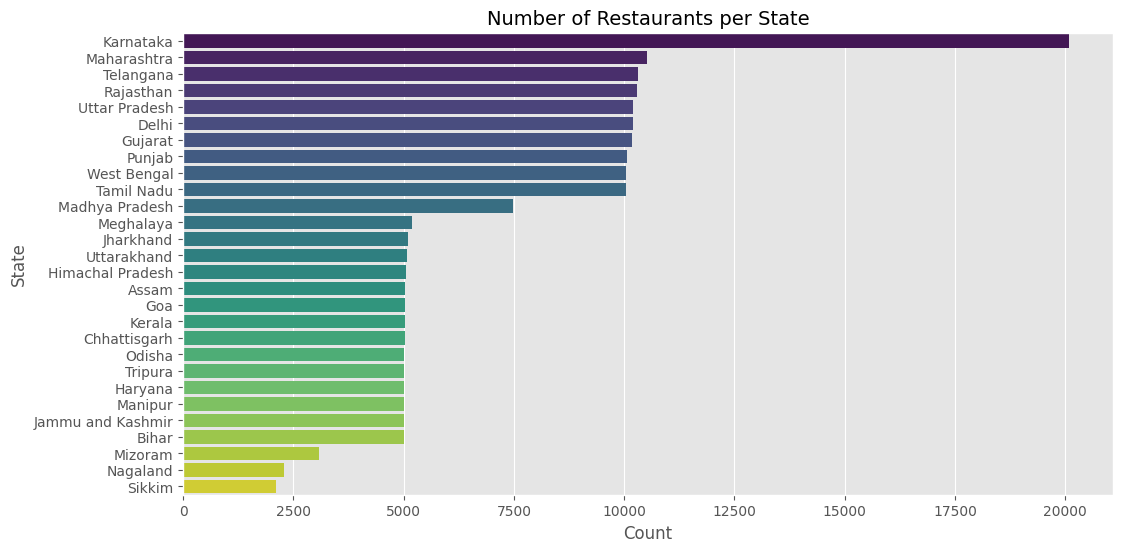

In [11]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y="State", order=df['State'].value_counts().index, palette="viridis")
plt.title("Number of Restaurants per State", fontsize=14)
plt.xlabel("Count")
plt.ylabel("State")
plt.show()

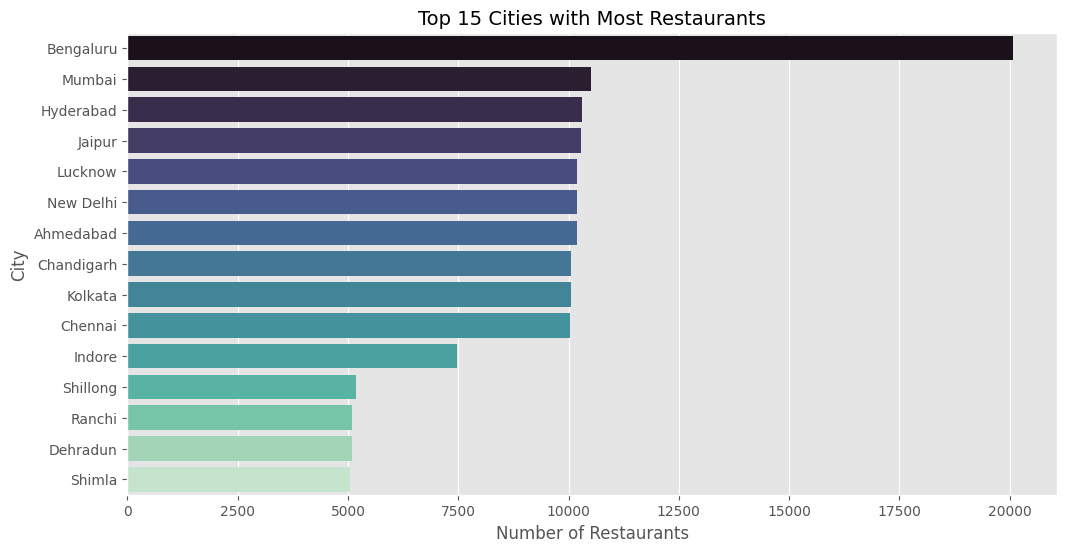

In [12]:
plt.figure(figsize=(12,6))
top_cities = df['City'].value_counts().head(15)
sns.barplot(x=top_cities.values, y=top_cities.index, palette="mako")
plt.title("Top 15 Cities with Most Restaurants", fontsize=14)
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.show()

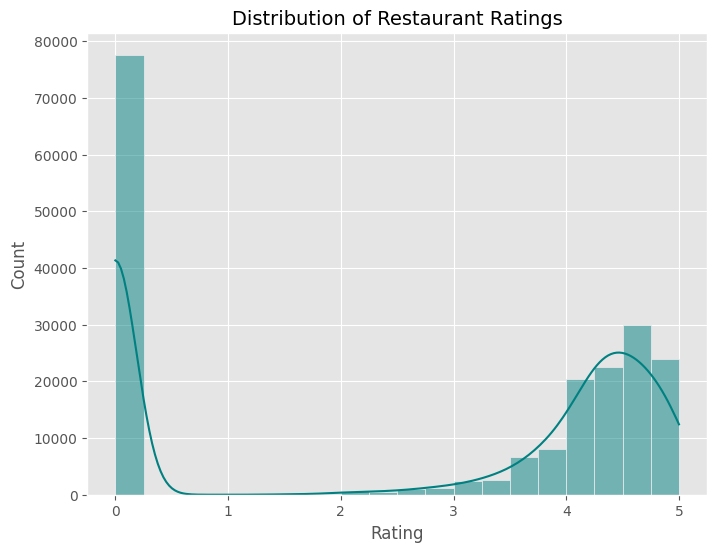

In [13]:
plt.figure(figsize=(8,6))
sns.histplot(df['Rating'], bins=20, kde=True, color="teal")
plt.title("Distribution of Restaurant Ratings", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


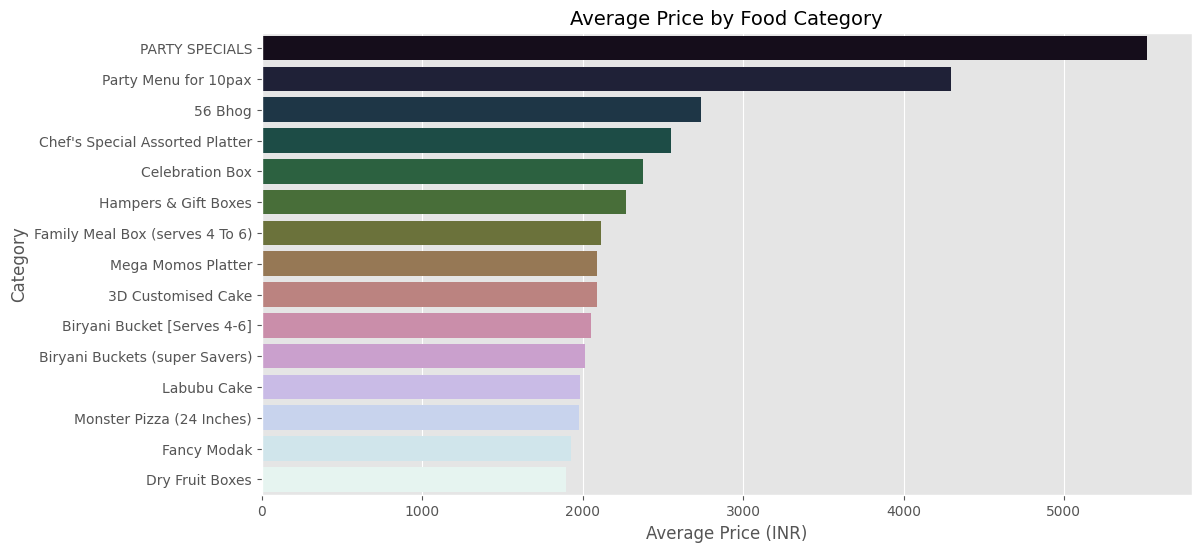

In [14]:
plt.figure(figsize=(12,6))
avg_price = df.groupby("Category")["Price (INR)"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=avg_price.values, y=avg_price.index, palette="cubehelix")
plt.title("Average Price by Food Category", fontsize=14)
plt.xlabel("Average Price (INR)")
plt.ylabel("Category")
plt.show()

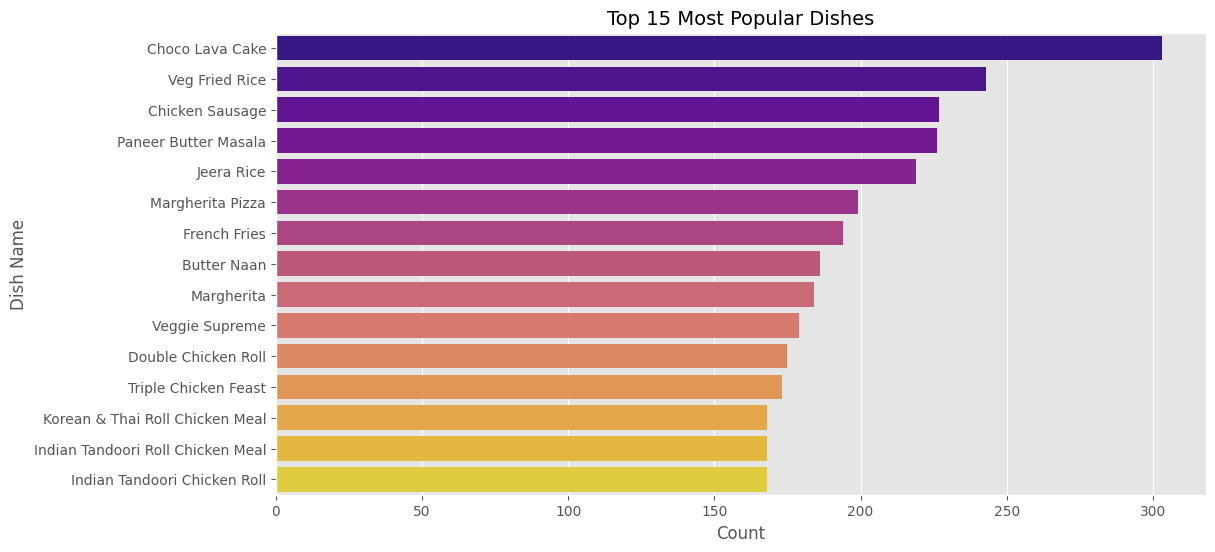

In [15]:
plt.figure(figsize=(12,6))
top_dishes = df['Dish Name'].value_counts().head(15)
sns.barplot(x=top_dishes.values, y=top_dishes.index, palette="plasma")
plt.title("Top 15 Most Popular Dishes", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Dish Name")
plt.show()

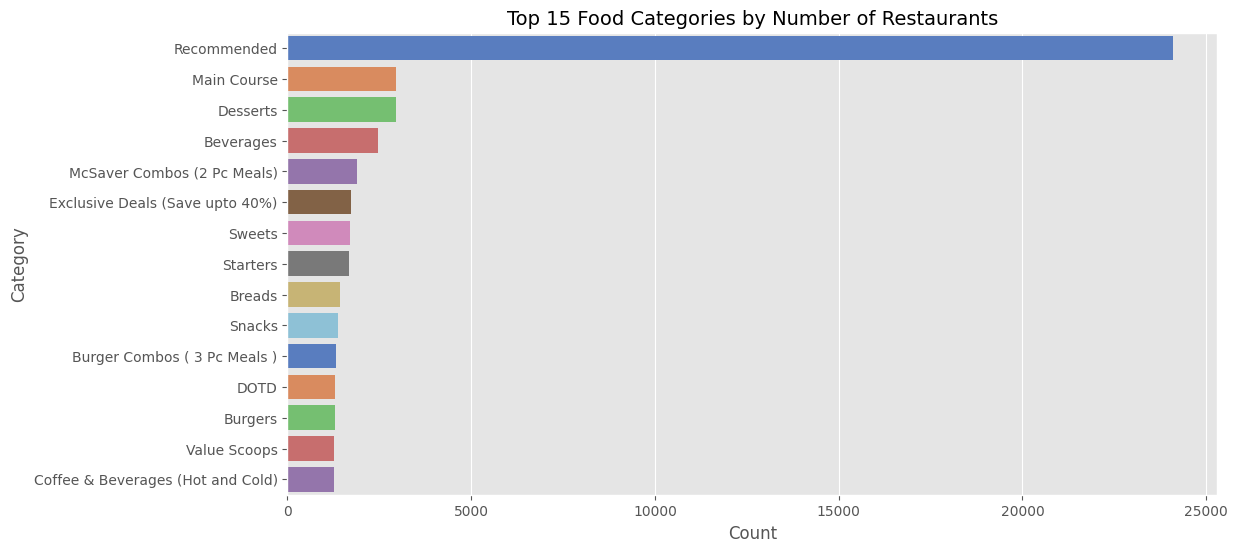

In [16]:
plt.figure(figsize=(12,6))
top_categories = df['Category'].value_counts().head(15)
sns.barplot(x=top_categories.values, y=top_categories.index, palette="muted")
plt.title("Top 15 Food Categories by Number of Restaurants", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

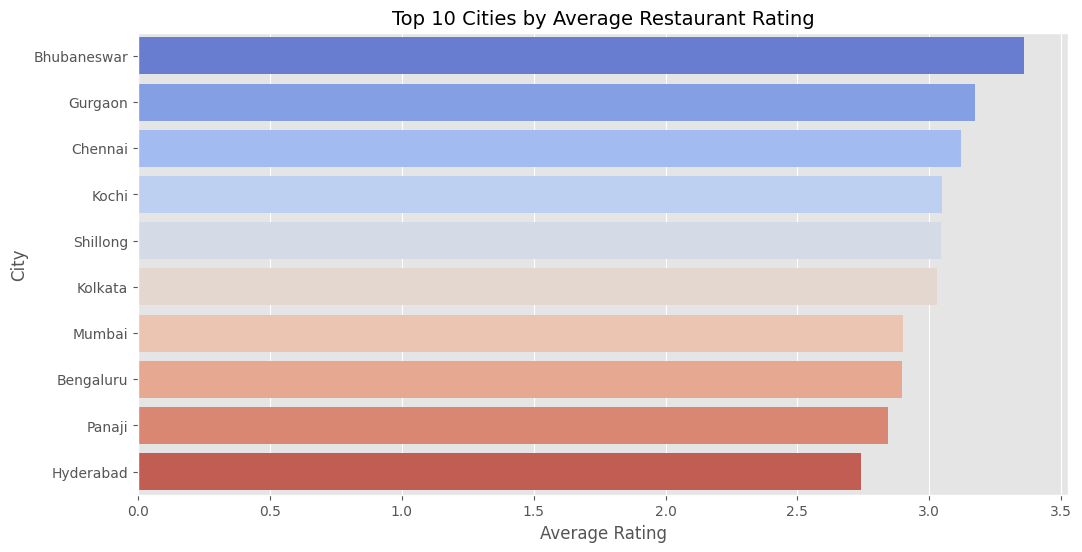

In [17]:
plt.figure(figsize=(12,6))
avg_rating_city = df.groupby("City")["Rating"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_rating_city.values, y=avg_rating_city.index, palette="coolwarm")
plt.title("Top 10 Cities by Average Restaurant Rating", fontsize=14)
plt.xlabel("Average Rating")
plt.ylabel("City")
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

In [19]:
df['High_Rating'] = df['Rating'].apply(lambda x: 1 if x >= 4 else 0)

In [20]:
df = df.dropna()

In [21]:
categorical_cols = ['State', 'City', 'Restaurant Name', 'Location', 'Category', 'Dish Name']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [22]:
X = df[['State', 'City', 'Restaurant Name', 'Location', 'Category', 
        'Dish Name', 'Price (INR)', 'Rating Count']]
y = df['High_Rating']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}


In [25]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    results.append((name, acc))


In [26]:
print("Model Performance (Accuracy %):\n")
for name, acc in results:
    print(f"{name}: {acc:.2f}%")

Model Performance (Accuracy %):

Logistic Regression: 70.92%
Decision Tree: 84.39%
Random Forest: 89.04%
Gradient Boosting: 87.52%
XGBoost: 88.14%
SVM: 55.56%
KNN: 66.85%


## Thank you..pls upvote!!!!